<a href="https://colab.research.google.com/github/RobertJacanin/bte320/blob/main/Pandas_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Analysis assignment (20 points)

You have been given the dataset `travel-times` in a CSV format. This dataset comes from a driver that uses an app to track GPS coordinates as he drives to work and back each day. The app collects the location and elevation data. In total, data for about 200 trips are summarized in this data set.

Load the `travel-times` in a `df` variable using `pandas` and then perform the following:
- print the shape of the dataset **(1 points)**
- print the first 15 rows of the dataset **(1 points)**
- get information for the features (columns) with missing values **(1 points)**
- drop duplicate values (if any) by keeping only the last instance **(1 points)**
- calculate the total number of missing values (if any) on each column **(2 points)**
- create two copies of the dataframe, and then:
    - drop rows with missing values from the 1st copy **(1 points)**
    - drop columns with missing values from the 2nd copy **(1 points)**
- get summary statistics and see the correlation between the numerical columns **(1 points)**
- show rows 11 to 14 **(1 points)**
- create a subset with trips occurred on November 23, 2011 and January 6, 2012 **(2 points)**
- produce a scatterplot between `Distance` and `TotalTime` **(1 points)**
    * Use:
```python
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20, 'figure.figsize': (10, 8)})
```
- produce boxplots for `AvgSpeed` and `AvgMovingSpeed` (use different cells for each) **(2 points)**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({'font.size': 20, 'figure.figsize': (10, 8)})

In [3]:
df = pd.read_csv("travel-times.csv")

In [4]:
# print the shape of the dataset (1 points)
df.shape

(205, 13)

In [5]:
# print the first 15 rows of the dataset (1 points)
df.head(15)

,Date,StartTime,DayOfWeek,GoingTo,Distance,MaxSpeed,AvgSpeed,AvgMovingSpeed,FuelEconomy,TotalTime,MovingTime,Take407All,Comments
0,1/6/2012,16:37,Friday,Home,51.29,127.4,78.3,84.8,NaN,39.3,36.3,No,NaN
1,1/6/2012,08:20,Friday,GSK,51.63,130.3,81.8,88.9,NaN,37.9,34.9,No,NaN
2,1/4/2012,16:17,Wednesday,Home,51.27,127.4,82.0,85.8,NaN,37.5,35.9,No,NaN
3,1/4/2012,07:53,Wednesday,GSK,49.17,132.3,74.2,82.9,NaN,39.8,35.6,No,NaN
4,1/3/2012,18:57,Tuesday,Home,51.15,136.2,83.4,88.1,NaN,36.8,34.8,No,NaN
5,1/3/2012,07:57,Tuesday,GSK,51.80,135.8,84.5,88.8,NaN,36.8,35.0,No,NaN
6,1/2/2012,17:31,Monday,Home,51.37,123.2,82.9,87.3,-,37.2,35.3,No,NaN
7,1/2/2012,07:34,Monday,GSK,49.01,128.3,77.5,85.9,-,37.9,34.3,No,NaN
8,12/23/2011,08:01,Friday,GSK,52.91,130.3,80.9,88.3,8.89,39.3,36.0,No,NaN
9,12/22/2011,17:19,Thursday,Home,51.17,122.3,70.6,78.1,8.89,43.5,39.3,No,NaN


In [24]:
# get information for the features (columns) with missing values (1 points)
missing = df.columns[df.isnull().any()]
print(df[missing].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   FuelEconomy  188 non-null    object
 1   Comments     24 non-null     object
dtypes: object(2)
memory usage: 3.3+ KB
None


In [7]:
# drop duplicate values (if any) by keeping only the last instance (1 points)
df = df.drop_duplicates(keep='last')

In [8]:
# calculate the total number of missing values (if any) on each column (2 points)
print(df.isnull().sum())

Date                0
StartTime           0
DayOfWeek           0
GoingTo             0
Distance            0
MaxSpeed            0
AvgSpeed            0
AvgMovingSpeed      0
FuelEconomy        17
TotalTime           0
MovingTime          0
Take407All          0
Comments          181
dtype: int64


In [11]:
# create two copies of the dataframe, and then:
# drop rows with missing values from the 1st copy (1 points)
# drop columns with missing values from the 2nd copy (1 points)

df_drop_rows = df.copy()
df_drop_cols = df.copy()

df_drop_rows.dropna(axis=0, inplace=True)
df_drop_cols.dropna(axis=1, inplace=True)

In [12]:
# get summary statistics and see the correlation between the numerical columns (1 points)

print(df.describe())
print(df.select_dtypes(include='number').corr())

         Distance    MaxSpeed    AvgSpeed  AvgMovingSpeed   TotalTime  \
count  205.000000  205.000000  205.000000      205.000000  205.000000   
mean    50.981512  127.591707   74.477561       81.975610   41.904390   
std      1.321205    4.128450   11.409816       10.111544    6.849476   
min     48.320000  112.200000   38.100000       50.300000   28.200000   
25%     50.650000  124.900000   68.900000       76.600000   38.400000   
50%     51.140000  127.400000   73.600000       81.400000   41.300000   
75%     51.630000  129.800000   79.900000       86.000000   44.400000   
max     60.320000  140.900000  107.700000      112.100000   82.300000   

       MovingTime  
count  205.000000  
mean    37.871707  
std      4.835072  
min     27.100000  
25%     35.700000  
50%     37.600000  
75%     39.900000  
max     62.400000  
                Distance  MaxSpeed  AvgSpeed  AvgMovingSpeed  TotalTime  \
Distance        1.000000  0.145091 -0.006445        0.011874   0.197207   
MaxSpeed    

In [14]:
# show rows 11 to 14 (1 points)

print(df.iloc[10:15])

          Date StartTime  DayOfWeek GoingTo  Distance  MaxSpeed  AvgSpeed  \
10  12/22/2011     08:16   Thursday     GSK     49.15     129.4      74.0   
11  12/21/2011     07:45  Wednesday     GSK     51.77     124.8      71.7   
12  12/20/2011     16:05    Tuesday    Home     51.45     130.1      75.2   
13  12/20/2011     06:04    Tuesday     GSK     49.01     119.0      77.4   
14  12/19/2011     16:18     Monday    Home     51.04     132.2      77.5   

    AvgMovingSpeed FuelEconomy  TotalTime  MovingTime Take407All Comments  
10            81.4        8.89       39.8        36.2         No      NaN  
11            78.9        8.89       43.3        39.4         No      NaN  
12            82.7        8.89       41.1        37.3         No      NaN  
13            82.0        8.89       38.0        35.9         No      NaN  
14            83.5        8.89       39.5        36.7         No      NaN  


In [15]:
# create a subset with trips occurred on November 23, 2011 and January 6, 2012 (2 points)

df['Date'] = pd.to_datetime(df['Date'])
mask = df['Date'].isin([pd.Timestamp('2011-11-23'), pd.Timestamp('2012-01-06')])
print(df[mask])

         Date StartTime  DayOfWeek GoingTo  Distance  MaxSpeed  AvgSpeed  \
0  2012-01-06     16:37     Friday    Home     51.29     127.4      78.3   
1  2012-01-06     08:20     Friday     GSK     51.63     130.3      81.8   
44 2011-11-23     16:17  Wednesday    Home     60.32     129.4      68.9   
45 2011-11-23     07:22  Wednesday     GSK     51.60     126.4      67.3   

    AvgMovingSpeed FuelEconomy  TotalTime  MovingTime Take407All Comments  
0             84.8         NaN       39.3        36.3         No      NaN  
1             88.9         NaN       37.9        34.9         No      NaN  
44            74.6         9.3       52.5        48.5         No      NaN  
45            73.6         9.3       46.0        42.1         No      NaN  


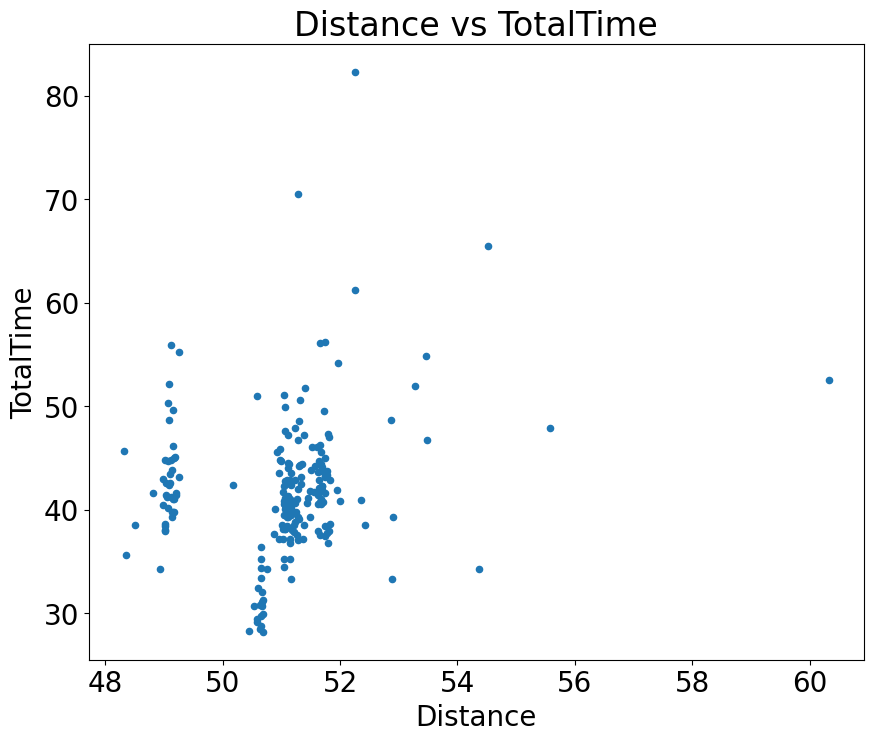

In [22]:
# produce a scatterplot between Distance and TotalTime (1 points)

import matplotlib.pyplot as plt

df.plot.scatter(x='Distance', y='TotalTime')
plt.title('Distance vs TotalTime')
plt.show()

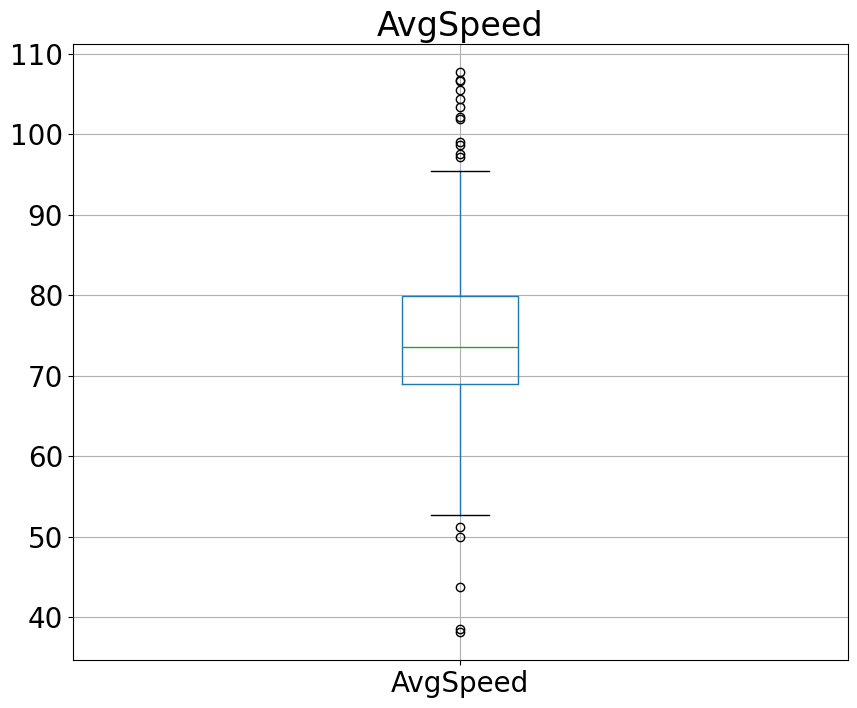

In [21]:
# boxplot for avg speed

df.boxplot(column='AvgSpeed')
plt.title('AvgSpeed')
plt.show()

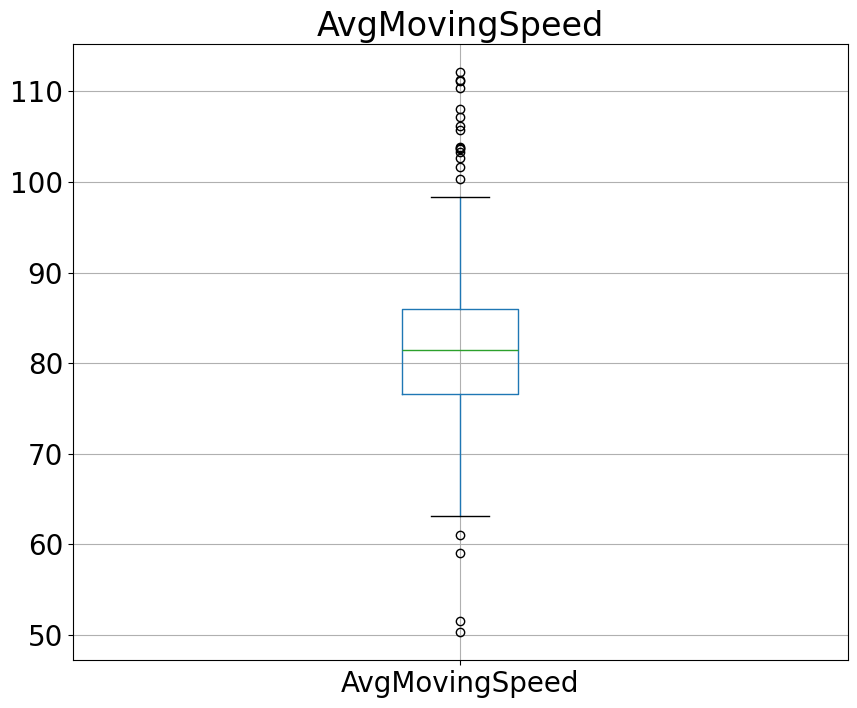

In [20]:
# boxplot for AvgMovingSpeed

df.boxplot(column='AvgMovingSpeed')
plt.title('AvgMovingSpeed')
plt.show()